# Project HR

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import pandas as pd

In [3]:
df=pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

In [4]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [5]:
num_col=list(df.describe().columns)
col_categorical=list(set(df.columns).difference(num_col))
remove_list=['EmployeeCount','EmployeeNumber','StandardHours']
col_numerical=[e for e in num_col if e not in remove_list]
attrition_to_num={'Yes':0,
                  'No':1}
df['Attrition_num']=df['Attrition'].map(attrition_to_num)
col_categorical.remove('Attrition')
df_cat = pd.get_dummies(df[col_categorical], dtype=int)
X=pd.concat([df[col_numerical],df_cat],axis=1)
y=df['Attrition_num']

## Decision Tree

In [6]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y)

In [8]:
from sklearn.tree import DecisionTreeClassifier

In [9]:
clf=DecisionTreeClassifier(random_state=42)

In [10]:
clf.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [14]:
from sklearn import preprocessing
from sklearn.model_selection import cross_val_score,cross_val_predict
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix, roc_auc_score

In [15]:
def print_score(clf, X_train, X_test, y_train, y_test, train=True):
    
    lb = preprocessing.LabelBinarizer()
    lb.fit(y_train)
    
    if train:
        res = clf.predict(X_train)
        print("Train result:\n")
        print("Accuracy score: {0:.4f}\n".format(accuracy_score(y_train, res)))
        print("Classification report:\n{}\n".format(classification_report(y_train, res)))
        print("Confusion matrix:\n{}\n".format(confusion_matrix(y_train, res)))
        
        res=cross_val_score(clf,X_train,y_train,cv=10,scoring='accuracy')
        print("Average accuracy :\t{0:.4f}".format(np.mean(res)))
        print("Accuracy SD:\t\t{0:.4f}".format(np.std(res)))
        
    else:
        res_test = clf.predict(X_test)
        print("Test result:\n")
        print("Accuracy score: {0:.4f}\n".format(accuracy_score(y_test, res_test)))
        print("Classification report:\n{}\n".format(classification_report(y_test, res_test)))
        print("Confusion matrix:\n{}\n".format(confusion_matrix(y_test, res_test)))
    

In [16]:
print_score(clf,X_train,X_test,y_train,y_test,train=True)
print("\n************************")
print_score(clf,X_train,X_test,y_train,y_test,train=False)

Train result:

Accuracy score: 1.0000

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       181
           1       1.00      1.00      1.00       921

    accuracy                           1.00      1102
   macro avg       1.00      1.00      1.00      1102
weighted avg       1.00      1.00      1.00      1102


Confusion matrix:
[[181   0]
 [  0 921]]

Average accuracy :	0.7695
Accuracy SD:		0.0369

************************
Test result:

Accuracy score: 0.7935

Classification report:
              precision    recall  f1-score   support

           0       0.31      0.30      0.31        56
           1       0.88      0.88      0.88       312

    accuracy                           0.79       368
   macro avg       0.60      0.59      0.59       368
weighted avg       0.79      0.79      0.79       368


Confusion matrix:
[[ 17  39]
 [ 37 275]]



Now we compare the decision tree classifier output values with different ensemble methods.

## Bagging Classifier

In [17]:
from sklearn.ensemble import BaggingClassifier

In [18]:
bag_clf=BaggingClassifier(estimator=clf,n_estimators=100,
                          bootstrap=True,n_jobs=-1,
                          random_state=42)

In [19]:
bag_clf.fit(X_train,y_train)

,estimator,DecisionTreeC...ndom_state=42)
,n_estimators,100
,max_samples,1.0
,max_features,1.0
,bootstrap,True
,bootstrap_features,False
,oob_score,False
,warm_start,False
,n_jobs,-1
,random_state,42
,verbose,0


In [21]:
print_score(bag_clf,X_train,X_test,y_train,y_test,train=True)
print("\n************************")
print_score(bag_clf,X_train,X_test,y_train,y_test,train=False)

Train result:

Accuracy score: 1.0000

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       181
           1       1.00      1.00      1.00       921

    accuracy                           1.00      1102
   macro avg       1.00      1.00      1.00      1102
weighted avg       1.00      1.00      1.00      1102


Confusion matrix:
[[181   0]
 [  0 921]]

Average accuracy :	0.8566
Accuracy SD:		0.0223

************************
Test result:

Accuracy score: 0.8696

Classification report:
              precision    recall  f1-score   support

           0       0.79      0.20      0.31        56
           1       0.87      0.99      0.93       312

    accuracy                           0.87       368
   macro avg       0.83      0.59      0.62       368
weighted avg       0.86      0.87      0.83       368


Confusion matrix:
[[ 11  45]
 [  3 309]]



## Random Forest

In [22]:
from sklearn.ensemble import RandomForestClassifier

In [23]:
rf_clf=RandomForestClassifier(random_state=42,n_estimators=100)

In [24]:
rf_clf.fit(X_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [25]:
print_score(rf_clf,X_train,X_test,y_train,y_test,train=True)
print("\n************************")
print_score(rf_clf,X_train,X_test,y_train,y_test,train=False)

Train result:

Accuracy score: 1.0000

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       181
           1       1.00      1.00      1.00       921

    accuracy                           1.00      1102
   macro avg       1.00      1.00      1.00      1102
weighted avg       1.00      1.00      1.00      1102


Confusion matrix:
[[181   0]
 [  0 921]]

Average accuracy :	0.8548
Accuracy SD:		0.0121

************************
Test result:

Accuracy score: 0.8668

Classification report:
              precision    recall  f1-score   support

           0       0.89      0.14      0.25        56
           1       0.87      1.00      0.93       312

    accuracy                           0.87       368
   macro avg       0.88      0.57      0.59       368
weighted avg       0.87      0.87      0.82       368


Confusion matrix:
[[  8  48]
 [  1 311]]



In [26]:
import seaborn as sns

<Axes: >

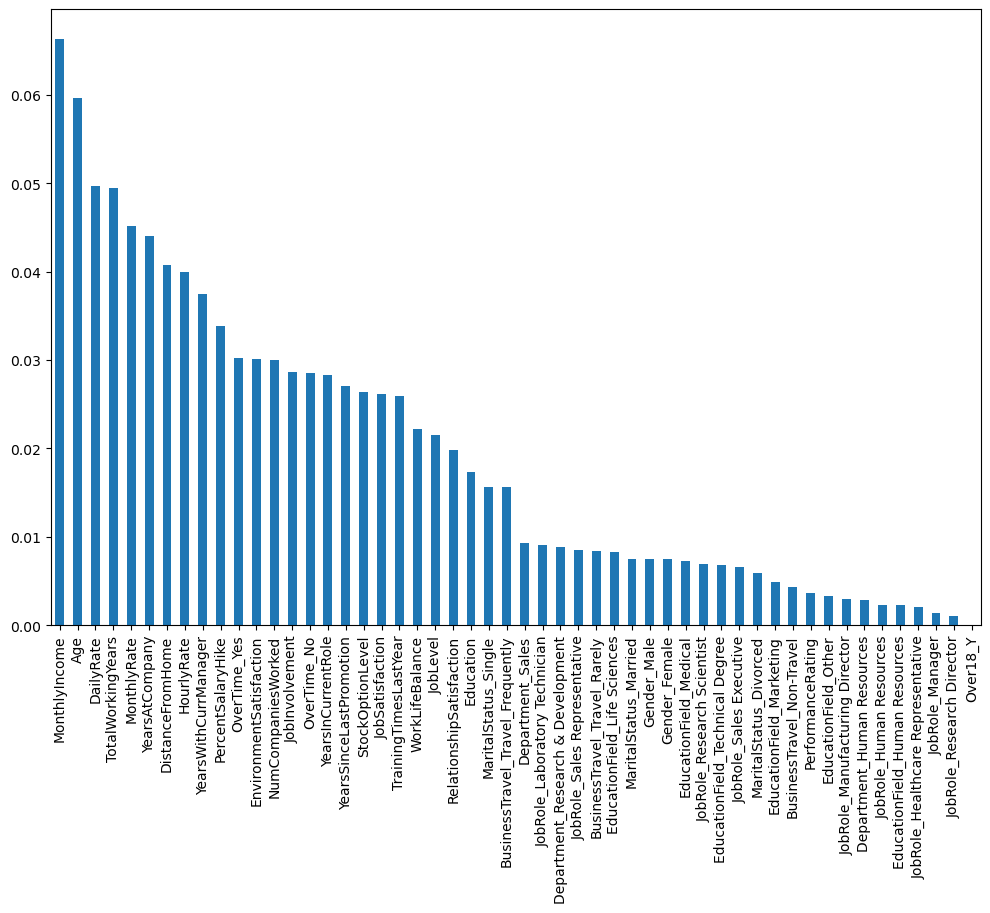

In [27]:
pd.Series(rf_clf.feature_importances_,
          index=X_train.columns).sort_values(ascending=False).plot(kind='bar',figsize=(12,8))

## AdaBoost

In [28]:
from sklearn.ensemble import AdaBoostClassifier

In [29]:
ada_clf=AdaBoostClassifier()

In [30]:
ada_clf.fit(X_train,y_train)

,estimator,None
,n_estimators,50
,learning_rate,1.0
,algorithm,'deprecated'
,random_state,None


In [31]:
print_score(ada_clf,X_train,X_test,y_train,y_test,train=True)
print("\n************************")
print_score(ada_clf,X_train,X_test,y_train,y_test,train=False)

Train result:

Accuracy score: 0.8829

Classification report:
              precision    recall  f1-score   support

           0       0.82      0.36      0.51       181
           1       0.89      0.98      0.93       921

    accuracy                           0.88      1102
   macro avg       0.86      0.67      0.72      1102
weighted avg       0.88      0.88      0.86      1102


Confusion matrix:
[[ 66 115]
 [ 14 907]]

Average accuracy :	0.8657
Accuracy SD:		0.0172

************************
Test result:

Accuracy score: 0.8668

Classification report:
              precision    recall  f1-score   support

           0       0.65      0.27      0.38        56
           1       0.88      0.97      0.93       312

    accuracy                           0.87       368
   macro avg       0.77      0.62      0.65       368
weighted avg       0.85      0.87      0.84       368


Confusion matrix:
[[ 15  41]
 [  8 304]]



## AdaBoost + RandomForest

In [34]:
ada_clf=AdaBoostClassifier(RandomForestClassifier(n_estimators=100),n_estimators=100)
ada_clf.fit(X_train,y_train.ravel())

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_15812\3704154238.py:2: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  ada_clf.fit(X_train,y_train.ravel())


,estimator,RandomForestClassifier()
,n_estimators,100
,learning_rate,1.0
,algorithm,'deprecated'
,random_state,None
,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0


In [35]:
print_score(ada_clf,X_train,X_test,y_train,y_test,train=True)
print("\n************************")
print_score(ada_clf,X_train,X_test,y_train,y_test,train=False)

Train result:

Accuracy score: 1.0000

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       181
           1       1.00      1.00      1.00       921

    accuracy                           1.00      1102
   macro avg       1.00      1.00      1.00      1102
weighted avg       1.00      1.00      1.00      1102


Confusion matrix:
[[181   0]
 [  0 921]]

Average accuracy :	0.8503
Accuracy SD:		0.0158

************************
Test result:

Accuracy score: 0.8668

Classification report:
              precision    recall  f1-score   support

           0       0.82      0.16      0.27        56
           1       0.87      0.99      0.93       312

    accuracy                           0.87       368
   macro avg       0.84      0.58      0.60       368
weighted avg       0.86      0.87      0.83       368


Confusion matrix:
[[  9  47]
 [  2 310]]



## Gradient Boosting Classifier

In [36]:
from sklearn.ensemble import GradientBoostingClassifier

In [38]:
gbc_clf=GradientBoostingClassifier(n_estimators=100)
gbc_clf.fit(X_train,y_train.ravel())

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_15812\2299953813.py:2: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  gbc_clf.fit(X_train,y_train.ravel())


,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [39]:
print_score(gbc_clf,X_train,X_test,y_train,y_test,train=True)
print("\n************************")
print_score(gbc_clf,X_train,X_test,y_train,y_test,train=False)

Train result:

Accuracy score: 0.9564

Classification report:
              precision    recall  f1-score   support

           0       0.98      0.75      0.85       181
           1       0.95      1.00      0.97       921

    accuracy                           0.96      1102
   macro avg       0.97      0.87      0.91      1102
weighted avg       0.96      0.96      0.95      1102


Confusion matrix:
[[136  45]
 [  3 918]]

Average accuracy :	0.8575
Accuracy SD:		0.0110

************************
Test result:

Accuracy score: 0.8614

Classification report:
              precision    recall  f1-score   support

           0       0.69      0.16      0.26        56
           1       0.87      0.99      0.92       312

    accuracy                           0.86       368
   macro avg       0.78      0.57      0.59       368
weighted avg       0.84      0.86      0.82       368


Confusion matrix:
[[  9  47]
 [  4 308]]



## XGBoost

In [42]:
import xgboost as xgb

In [43]:
xgb_clf=xgb.XGBClassifier(n_estimators=100)
xgb_clf.fit(X_train,y_train.ravel())

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_15812\995200558.py:2: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  xgb_clf.fit(X_train,y_train.ravel())


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [44]:
print_score(xgb_clf,X_train,X_test,y_train,y_test,train=True)
print("\n************************")
print_score(xgb_clf,X_train,X_test,y_train,y_test,train=False)

Train result:

Accuracy score: 1.0000

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       181
           1       1.00      1.00      1.00       921

    accuracy                           1.00      1102
   macro avg       1.00      1.00      1.00      1102
weighted avg       1.00      1.00      1.00      1102


Confusion matrix:
[[181   0]
 [  0 921]]

Average accuracy :	0.8512
Accuracy SD:		0.0205

************************
Test result:

Accuracy score: 0.8668

Classification report:
              precision    recall  f1-score   support

           0       0.67      0.25      0.36        56
           1       0.88      0.98      0.93       312

    accuracy                           0.87       368
   macro avg       0.77      0.61      0.64       368
weighted avg       0.85      0.87      0.84       368


Confusion matrix:
[[ 14  42]
 [  7 305]]

